# Part 3: Gradient-enhanced surrogate modeling and GSA

In this part is we perform surrogate modeling and Global Sensitivity Analysis (GSA) when gradient evaluations of the model are available.

Consider the following toy model, already used in [Adcock and sui (2019)](https://link.springer.com/article/10.1007/s00365-019-09467-0) and [Roustant et al. (2025)](https://arxiv.org/abs/2510.03056)

$$\mathcal{M}(X_1,\dots,X_4)=\prod_{i=1}^4 \frac{1}{1+(X_i-a_i)^2},\quad a_i=\frac{(-1)^j}{j+1},\quad X_i\sim \mathcal{U}(-1,1).$$

The advantage of using uniform distributions is that their bases (orthogonal polynomials and Poincaré) are explicitly known, which allows to apply our method directly. The method implemented for general probability measures will be available soon in [UQLab](https://www.uqlab.com/).

### Packages and preparation

In [18]:
import numpy as np
import matplotlib.pyplot as plt

import toy
import gradient_enhanced

## Model set

In [19]:
# Input and corresponding outputs

N = 40
d = 4

# Input
X = toy.getSample(N)
# Model evaluations
Y = toy.model(X)
# Gradient evaluations, computed using finite differences
Ygrad = toy.model_gradient(X)
# So for instance, 
Ygrad[:,0] # are the evaluations of the first derivative

array([-0.0516948 ,  0.48276032, -0.16643523, -0.12645278,  0.05696954,
       -0.24733146, -0.16396464, -0.31295909, -0.32785032, -0.16350738,
       -0.07386346,  0.11172932, -0.00368769,  0.0910849 , -0.08735361,
       -0.16535537,  0.47453039, -0.17916238, -0.23358857, -0.21567275,
       -0.32416897, -0.06579726, -0.34585653, -0.26880577, -0.22956914,
        0.23920936, -0.33058272, -0.11743464,  0.34700655,  0.11162016,
       -0.37867752, -0.09255996,  0.15261684, -0.45513908,  0.03458496,
       -0.1597389 ,  0.22534209, -0.09928513, -0.2932383 , -0.37733502])

## Classical Poincaré basis

The Poincaré bases are well suited to perform gradient-enhanced surrogate modeling and GSA, when gradient evaluations of the model are available.
In this example we use the classical Poincaré basis (that is, with constant weight $w=1$) for the uniform distribution $\mathcal{U}([-1,1])$. However, other Poincaré bases can be considered by changing the weight $w$.

Recall that the classical Poincaré basis $(\psi_n)_{n\geq 0}$ is given by the solutions of the spectral problem:

$$ \begin{cases}
-Lg = -g'' = \lambda g,\quad \mbox{with }\lambda\geq 0 \\
g'(-1)=g'(1)=0
    \end{cases}.$$


<div class="alert alert-block alert-success">
    <b>Task:</b> Verify that the solutions are:
$$\phi_0(x)=1,\quad \phi_n(x)=\cos\left(\pi\, n\, \left(\frac{x+1}{2}\right)\right),\quad x\in (-1,1),\quad \lambda_n= (\pi \, n /2)^2,\quad n\geq 0$$.
</div>

We store the Poincaré basis functions and their derivatives. We set the maximum degree $p$ of the eigenfunction to be used.

In [20]:
# Basis functions storage

p = 5  # Max degree

poincare_basis = [] # The eigenfunctions go here
poincare_basis_der = [] # The derivatives of the eigenfunctions go here

for n in range(p+1):
    def poincare_eigenf(x, n=n):
        return np.cos(n*np.pi*(x+1)/2)
    def poincare_eigenf_der(x, n=n):
        if n== 0:
            return 0*x
        else:
            return - (n*np.pi/2) *np.sin(n*np.pi*(x+1)/2)

    poincare_basis.append(poincare_eigenf)
    poincare_basis_der.append(poincare_eigenf_der)

### Gradient-enhanced approximations using the Poincaré basis

In order to perfom the gradient-enhanced method we follow the steps below:

1. Set an initial set of multi-indices $\mathcal{A}\subseteq \mathbb{N}^d$.
2. Construct the block matrices of basis functions evaluations $\Psi$, $\Psi_{\partial_1},\dots,\Psi_{\partial_d}$, defined as
   $$\Psi_{i\, \alpha} = \psi_\alpha( x^{(i)}) = \psi_{\alpha_1}( x_1^{(i)}) \dots \psi_{\alpha_d}( x_d^{(i)})
,\qquad(\Psi_{\partial_k})_{i\,\alpha} = \frac{\partial \psi_\alpha}{\partial x_k}( x^{(i)}) = \psi_1( x_{\alpha_1}^{(i)})\dots \psi_{\alpha_k}'( x_k^{(i)}) \dots \psi_{\alpha_d}( x_d^{(i)}).
$$
Note that the matrices indexation include multi-indices $\alpha$. They are asummed to have some ordering in the set $\mathcal{A}$.

3. Construct a large combined matrix and collect all model and gradient evaluations in a single vector
$$\Psi_{\mathrm{comb}} = \begin{bmatrix}
         \Psi \\
         \Psi_{\partial_1} \\
        \vdots \\
        \Psi_{\partial_d}
    \end{bmatrix},\qquad y_{\mathrm{comb}} = \begin{bmatrix}
         y \\
         y_{\partial_1} \\
        \vdots \\
        y_{\partial_d},
    \end{bmatrix}$$
where $(y_{\partial_k})_i=\frac{\partial}{\partial x_k}\mathcal{M}(x^{(i)})$.

4. Aiming at building and approximation of the model $\mathcal{M}=\sum_{\mathcal{A}} c_\alpha\,\psi_\alpha $, one seeks to compute a coeffients vector $c_{\mathrm{comb}}$ such that $$ \Psi_{\mathrm{comb}} \, c_{\mathrm{comb}} \approx y_{\mathrm{comb}}$$. This is achieved by solving the sparse regression problem
   $$\displaystyle \min_{ c} \left(||\Psi  c- y||_{2}^2+\sum_{k=1}^d||\Psi_{\partial_k}  c- y_{\partial_k}||_{2}^2+\gamma ||c||_{1}\right).$$


The function `solve_surrogate_system` in the code chunk below constructs the regression matrix and computes the vector $c$ by solving the regression problem.

<div class="alert alert-block alert-success">
    <b>Task:</b> 
    <ul>
        <li>Have a look at the implementation of <code>solve_surrogate_system</code> in the <code>gradient_enhanced.py</code> file and identify each step.</li>
        <li>What is the initial set of multi-indices $\mathcal{A}$?</li>
        <li>Which solver is used to compute the coefficients vector $c$?</li>
    </ul>
</div>

This functions provides everything:
- The matrix $ \Psi $ (without derivatives).
- The coefficient vector $c$ obtained by solving $\Psi c\approx y$
- The combined matrix $ \Psi_{\mathrm{comb}}$.
- The coefficient $ c_{\mathrm{comb}}$ obtained by solving $\Psi_{\mathrm{comb}}\, c_{\mathrm{comb}}\approx y_{\mathrm{comb}}$.

In [21]:
myPoinCE = gradient_enhanced.solve_surrogate_system(X, Y, Ygrad, poincare_basis, poincare_basis_der)

# It provides multiple things:

r_matrix = myPoinCE['matrix'] # \Psi

coeff = myPoinCE['coefficients'] # c

r_matrix_comb = myPoinCE['large_matrix'] # \Psi_comb

coeff_comb = myPoinCE['grad_enhanced_coefficients'] # c_comb

## Gradient-enhanced surrogate modeling

The function `surrogate_constructor` below can create both the surrogate model $\widehat{\mathcal{M}}=\sum_{\mathcal{A}} c_\alpha\,\psi_\alpha$ and the surrogate derivatives $\frac{\partial}{\partial x_k}\widehat{\mathcal{M}}=\sum_{\mathcal{A}} c_\alpha\,\psi_\alpha$, given the family of basis functions and a coefficients vector $c$.

In [22]:
My_surr = gradient_enhanced.surrogate_constructor(poincare_basis, poincare_basis_der, coeff, deriv_idx=-1) # Set deriv_idx = -1 for the surrogate model
My_surr_comb = gradient_enhanced.surrogate_constructor(poincare_basis, poincare_basis_der, coeff_comb, deriv_idx=-1)

# To store the partial derivatives
My_surr_der = []
My_surr_der_comb = []

for k in range(d):
    My_surr_der_k = gradient_enhanced.surrogate_constructor(poincare_basis, poincare_basis_der, coeff, deriv_idx=k) # k-th partial derivative
    My_surr_der_comb_k = gradient_enhanced.surrogate_constructor(poincare_basis, poincare_basis_der, coeff_comb, deriv_idx=k)
    
    My_surr_der.append(My_surr_der_k)
    My_surr_der_comb.append(My_surr_der_comb_k)

## Validation

Once the surrogate models are constructed, we test their performances with $L^2$ and the $H^1$ errors. They are defined using a new independent validation sample $X_{\mathrm{val}}$ as


$$ E_{L^2} =  \mathbb{E}\left[\left(\mathcal{M}(X_{\mathrm{val}}) - \widehat{\mathcal{M}}(X_{\mathrm{val}})\right)^2\right]$$

and

$$
E_{H^1} = \mathbb{E}\left[\left(\mathcal{M}(X_{\mathrm{val}}) - \widehat{\mathcal{M}}(X_{\mathrm{val}})\right)^2\right] + \sum_{k = 1}^d \mathbb{E}\left[\left(\frac{\partial}{\partial x_k}\mathcal{M}(X_{\mathrm{val}}) - \frac{\partial}{\partial x_k}\widehat{\mathcal{M}}(X_{\mathrm{val}})\right)^2\right]
$$

In [23]:
# Generate a new input sample
Xval = toy.getSample(1000)

# Evaluate the sample with the true model
Yval = toy.model(Xval)

# Evaluate the sample with the surrogate models
Ysurr_val = My_surr(Xval)
Ysurr_comb_val = My_surr_comb(Xval)

# Compute the L2 error
L2 = np.mean((Yval-Ysurr_val)**2)
L2_comb = np.mean((Yval-Ysurr_comb_val)**2)

# Do the same for the surrogate derivatives to compute the H^1 errors
H1 = L2
H1_comb = L2_comb
Yval_grad = toy.model_gradient(Xval)
for k in range(d):
    Ysurr_der_val_k = My_surr_der[k](Xval)
    Ysurr_der_comb_val_k = My_surr_der_comb[k](Xval)
    H1 = H1 + np.mean((Yval_grad[:,k]-Ysurr_der_val_k)**2)
    H1_comb = H1_comb + np.mean((Yval_grad[:,k]-Ysurr_der_comb_val_k)**2)

### Fancy plot

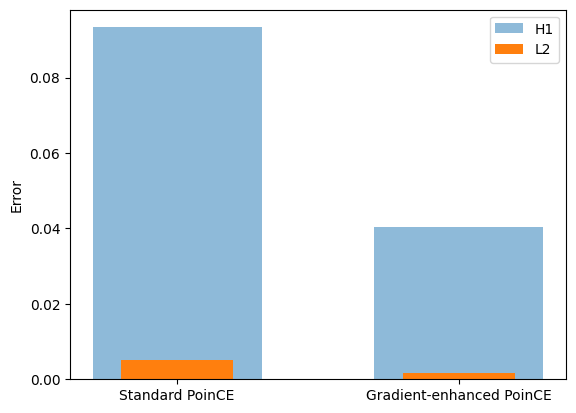

In [24]:
l = np.arange(2)  # two positions

labels = ['Standard PoinCE', 'Gradient-enhanced PoinCE']

# Plot H1 first (behind)
plt.bar(l, [H1, H1_comb], width=0.6, alpha=0.5, label='H1', zorder=1)
# Plot L2 on top
plt.bar(l, [L2, L2_comb], width=0.4, label='L2', zorder=2)

plt.xticks(l, labels)
plt.ylabel("Error")
plt.legend()
plt.show()

<div class="alert alert-block alert-success">
    <b>Task:</b> Impress yourself.
</div>

## Application to Global Sensitivity Analysis

The function `compute_sobol_indice` below computes first order and total Sobol indices from a given coefficient vector $c$.

In [25]:
mySobol_comb = gradient_enhanced.compute_sobol_indices(coeff_comb)

mySobol_first_comb = mySobol_comb['First_order']
mySobol_total_comb = mySobol_comb['Total']

print("For instance, using c_comb we obtain the total Sobol indices")

print(f"S_i^T : {mySobol_total_comb}")

For instance, using c_comb we obtain the total Sobol indices
S_i^T : [0.45775089 0.32115982 0.16309433 0.18371296]


## Comparison

We compare the classical method vs the gradient-enhanced one, using three different sample sizes.

In [26]:
# (It takes a while)

nSample = [40,80,160] # Sample sizes N
nRep = 5 # For each N in nSample, we repeat the numerical nRep times

TotalSobol = np.zeros((len(nSample),nRep,d)) # All the indices are stored here
TotalSobol_comb = np.zeros((len(nSample),nRep,d)) # All the indices are stored here

for i, N in enumerate(nSample):
    for k in range(nRep):

        X = toy.getSample(N)
        Y = toy.model(X)
        Ygrad = toy.model_gradient(X)
            
        myPoinCE = gradient_enhanced.solve_surrogate_system(X, Y, Ygrad, poincare_basis, poincare_basis_der)      
        
        coeff = myPoinCE['coefficients'] # c
        coeff_comb = myPoinCE['grad_enhanced_coefficients'] # c_comb

        mySobol = gradient_enhanced.compute_sobol_indices(coeff)
        mySobol_total = mySobol['Total']
        
        mySobol_comb = gradient_enhanced.compute_sobol_indices(coeff_comb)
        mySobol_comb_total = mySobol_comb['Total']
        
        TotalSobol[i, k, :] = mySobol_total
        TotalSobol_comb[i, k, :] = mySobol_comb_total

### Fancy boxplots

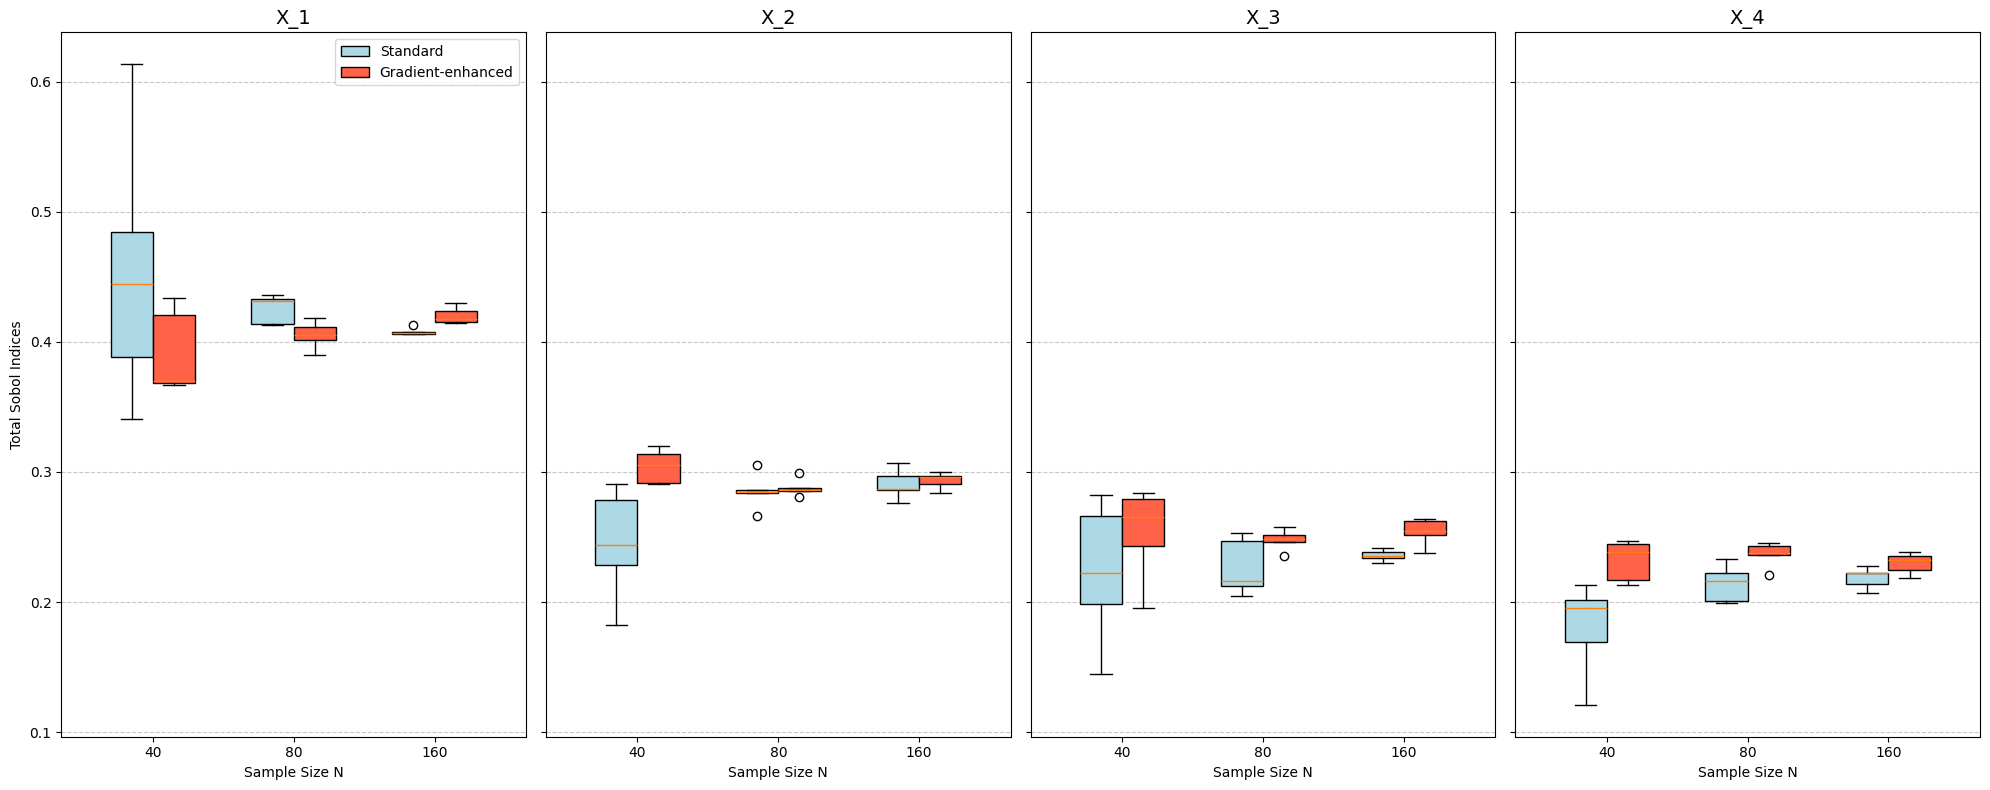

In [27]:
toyNames = ['X_1','X_2','X_3','X_4']
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 8), sharey=True)
axes = axes.flatten()

width = 0.3  # Width of each box

for i in range(d):
    ax = axes[i]
    
    positions = np.arange(len(nSample)) + 1 
    
    data_std = [TotalSobol[j, :, i] for j in range(len(nSample))]
    data_comb = [TotalSobol_comb[j, :, i] for j in range(len(nSample))]
    
    bp1 = ax.boxplot(data_std, positions=positions - width/2, widths=width, 
                     patch_artist=True, boxprops=dict(facecolor="lightblue"))
    
    bp2 = ax.boxplot(data_comb, positions=positions + width/2, widths=width, 
                     patch_artist=True, boxprops=dict(facecolor="tomato"))
    
    ax.set_xticks(positions)
    ax.set_xticklabels(nSample)
    ax.set_title(toyNames[i], fontsize=14)
    ax.set_xlabel('Sample Size N')
    if i == 0:
        ax.set_ylabel('Total Sobol Indices')
        ax.legend([bp1["boxes"][0], bp2["boxes"][0]], ['Standard', 'Gradient-enhanced'])
    
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Another Poincaré chaos expansion

Actually, the standard orthogonal polynomials basis $(P_n)_{n\geq 0}$ (Legendre polynomials) is another Poincaré basis, associated with the linear standard weight
$$ w_{\mathrm{lin}}(x)=(1-x^2)/2.$$
As such, the classical PCE matches with the Poincaré chaos expansion (without derivatives). Now we can perform gradient-enhanced surrogate modeling using this basis. 

Indeed, recall that the functions $(\sqrt{w_{\mathrm{lin}}}\,P'_n)_{n\geq 1}$ are orthogonal. Then we can repeat the same procedure using Legendre polynomials, but one has to modify the regression matrices and derivative evaluations as

$$(\Psi_{\partial_k})_{i\,\alpha} = \sqrt{w(x^{(i)})}\, \frac{\partial \psi_\alpha}{\partial x_k}( x^{(i)}) = \psi_1( x_{\alpha_1}^{(i)})\dots \sqrt{w(x^{(i)})}\,\psi_{\alpha_k}'( x_k^{(i)}) \dots \psi_{\alpha_d}( x_d^{(i)}),\qquad (y_{\partial_k})_i=\sqrt{w(x^{(i)})}\frac{\partial}{\partial x_k}\mathcal{M}(x^{(i)}).
$$

<div class="alert alert-block alert-success">
    <b>Difficult task:</b> Perform gradient-enhanced surrogate modeling and GSA using PCE (Legendre polynomials).
</div>

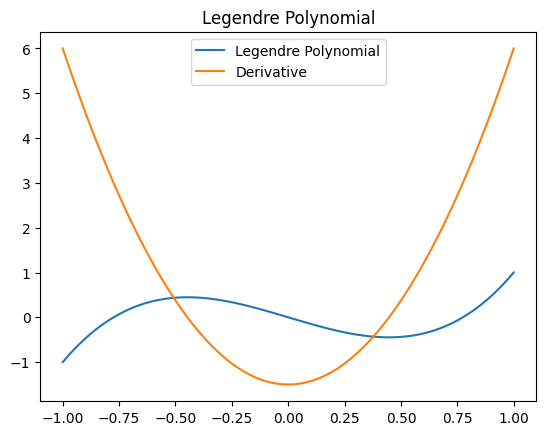

In [28]:
from numpy.polynomial.legendre import Legendre

# Legendre polynomial
poly_test = Legendre.basis(3)
x = np.linspace(-1,1,100)

plt.plot(x, poly_test(x), label="Legendre Polynomial")
plt.title("Legendre Polynomial")

# Derivative
poly_derivative_test = poly_test.deriv()

plt.plot(x, poly_derivative_test(x), label="Derivative")
plt.legend()
plt.show()